In [4]:
import json
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import re
import os

# ============================================
# КОНФИГУРАЦИЯ
# ============================================
MODEL_NAME = "Vikhrmodels/Vikhr-Qwen-2.5-0.5B-Instruct"
OUTPUT_DIR = "./personality_model_vikhr"
TRAIN_FILE = "train_prompts_0shot_clean.jsonl"
VAL_FILE = "val_prompts_0shot_clean.jsonl"
TEST_FILE = "test_prompts_0shot_clean.jsonl"

# Параметры обучения
BATCH_SIZE = 2  # Для 0.5B модели и 16GB VRAM
GRADIENT_ACCUMULATION = 4  # Эффективный batch = 8
LEARNING_RATE = 2e-4
NUM_EPOCHS = 5
MAX_LENGTH = 1536  # Максимальная длина токенов
LOGGING_STEPS = 10
SAVE_STEPS = 100
EVAL_STEPS = 100

# ============================================
# ШАГ 1: Загрузка данных из JSONL
# ============================================
def load_jsonl(file_path):
    """Загружает данные из JSONL файла"""
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

print("Загрузка данных...")
train_data = load_jsonl(TRAIN_FILE)
val_data = load_jsonl(VAL_FILE)
test_data = load_jsonl(TEST_FILE)

print(f"Train: {len(train_data)} примеров")
print(f"Validation: {len(val_data)} примеров")
print(f"Test: {len(test_data)} примеров")

# ============================================
# ШАГ 2: Подготовка данных для обучения
# ============================================

def create_training_example(item):
    """
    Преобразует пример в формат для обучения:
    - Промпт (все, что до "Формат ответа") + правильный JSON
    """
    prompt = item['prompt']
    true_labels = item['true_labels_russian']
    
    # Создаем правильный ответ в JSON формате
    completion = json.dumps(true_labels, ensure_ascii=False)
    
    # Объединяем промпт и ответ
    full_text = prompt + "\n\n" + completion
    
    # Для инструктивных моделей лучше использовать chat template
    # Извлекаем задачу и текст из промпта
    messages = [
        {
            "role": "system", 
            "content": "Вы - эксперт по психологическому анализу личности. Отвечайте строго в JSON формате."
        },
        {
            "role": "user", 
            "content": prompt
        },
        {
            "role": "assistant", 
            "content": completion
        }
    ]
    
    return {
        "text": full_text,
        "messages": messages,
        "completion": completion,
        "true_labels": true_labels
    }

# Подготавливаем данные
print("Подготовка тренировочных примеров...")
train_examples = [create_training_example(item) for item in train_data]
val_examples = [create_training_example(item) for item in val_data]
test_examples = [create_training_example(item) for item in test_data]

# ============================================
# ШАГ 3: Токенизация
# ============================================
print("Загрузка токенизатора...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Устанавливаем специальные токены
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

def tokenize_function(examples):
    """Токенизация с использованием chat_template"""
    # Применяем chat template
    tokenized = tokenizer.apply_chat_template(
        examples["messages"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
        return_dict=True
    )
    
    # Для causal LM labels = input_ids
    tokenized["labels"] = tokenized["input_ids"].copy()
    
    return tokenized

# Создаем датасеты
train_dataset = Dataset.from_list(train_examples)
val_dataset = Dataset.from_list(val_examples)
test_dataset = Dataset.from_list(test_examples)

# Токенизируем
print("Токенизация данных...")
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=train_dataset.column_names
)
tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=val_dataset.column_names
)
tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=test_dataset.column_names
)

# Создаем DatasetDict
dataset_dict = DatasetDict({
    'train': tokenized_train,
    'validation': tokenized_val,
    'test': tokenized_test
})

# ============================================
# ШАГ 4: Настройка модели с LoRA
# ============================================
print("Загрузка модели...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

# Подготовка модели для обучения с LoRA
model.enable_input_require_grads()

# Конфигурация LoRA
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,  # Ранг матрицы
    lora_alpha=32,  # Параметр масштабирования
    lora_dropout=0.1,  # Dropout для регуляризации
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    bias="none",
)

# Применяем LoRA
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# ============================================
# ШАГ 5: Коллбэк для сбора метрик
# ============================================

class PersonalityMetricsCallback:
    """Коллбэк для вычисления метрик качества"""
    
    def __init__(self, tokenizer, eval_dataset, original_val_data):
        self.tokenizer = tokenizer
        self.eval_dataset = eval_dataset
        self.original_val_data = original_val_data
        
    def extract_json_from_text(self, text):
        """Извлекает JSON из сгенерированного текста"""
        # Ищем JSON в ответе
        json_pattern = r'\{[^{}]*"открытость_опыту"[^{}]*\}'
        match = re.search(json_pattern, text)
        if match:
            try:
                return json.loads(match.group())
            except:
                pass
        
        # Запасной вариант - ищем любой JSON
        json_pattern = r'\{[^{}]*\}'
        matches = re.findall(json_pattern, text)
        for match_str in matches:
            try:
                parsed = json.loads(match_str)
                if 'открытость_опыту' in parsed:
                    return parsed
            except:
                continue
        return None
    
    def compute_metrics(self, model):
        """Вычисляет метрики на валидационной выборке"""
        model.eval()
        predictions = []
        targets = []
        
        # Берем первые 20 примеров для быстрой оценки
        sample_size = min(20, len(self.original_val_data))
        
        for i in range(sample_size):
            # Получаем текст для генерации
            example = val_examples[i]
            messages = example['messages'][:2]  # Берем system и user сообщения
            
            # Токенизируем
            inputs = self.tokenizer.apply_chat_template(
                messages,
                return_tensors="pt",
                truncation=True,
                max_length=MAX_LENGTH
            ).to(model.device)
            
            # Генерируем ответ
            with torch.no_grad():
                outputs = model.generate(
                    inputs,
                    max_new_tokens=100,
                    temperature=0.1,
                    do_sample=False,
                    pad_token_id=self.tokenizer.eos_token_id
                )
            
            generated = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
            predicted_json = self.extract_json_from_text(generated)
            
            if predicted_json:
                predictions.append(predicted_json)
                targets.append(example['true_labels'])
        
        if not predictions:
            return {"accuracy": 0.0, "f1": 0.0}
        
        # Вычисляем метрики для каждого признака
        traits = ['открытость_опыту', 'добросовестность', 'экстраверсия', 
                  'доброжелательность', 'нейротизм']
        
        accuracies = []
        f1_scores = []
        
        for trait in traits:
            y_true = [t[trait] for t in targets]
            y_pred = [p.get(trait, -1) for p in predictions]
            
            # Фильтруем непредсказанные
            valid_indices = [i for i, p in enumerate(y_pred) if p != -1]
            if valid_indices:
                y_true_valid = [y_true[i] for i in valid_indices]
                y_pred_valid = [y_pred[i] for i in valid_indices]
                
                acc = accuracy_score(y_true_valid, y_pred_valid)
                f1 = f1_score(y_true_valid, y_pred_valid, average='weighted')
                
                accuracies.append(acc)
                f1_scores.append(f1)
        
        model.train()
        
        return {
            "accuracy": np.mean(accuracies) if accuracies else 0.0,
            "f1": np.mean(f1_scores) if f1_scores else 0.0,
            "predictions_made": len(predictions)
        }

# Создаем коллбэк для метрик
metrics_callback = PersonalityMetricsCallback(tokenizer, tokenized_val, val_data)

# ============================================
# ШАГ 6: Настройка Trainer
# ============================================

# Data collator для языкового моделирования
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False  # Мы используем causal LM, не masked LM
)

# Аргументы обучения
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    warmup_steps=100,
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    eval_steps=EVAL_STEPS,
    eval_strategy="steps",
    save_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,  # Используем mixed precision
    gradient_checkpointing=True,  # Экономия памяти
    save_total_limit=3,
    remove_unused_columns=False,
    report_to="none",  # Отключаем wandb/tensorboard если не нужны
    # push_to_hub=False,
)

# Создаем Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict['train'],
    eval_dataset=dataset_dict['validation'],
    data_collator=data_collator,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# ============================================
# ШАГ 7: Запуск обучения
# ============================================
print("Начало обучения...")
print(f"Количество эпох: {NUM_EPOCHS}")
print(f"Размер батча: {BATCH_SIZE} x {GRADIENT_ACCUMULATION} = {BATCH_SIZE * GRADIENT_ACCUMULATION}")
print(f"Тренировочных примеров: {len(tokenized_train)}")
print(f"Валидационных примеров: {len(tokenized_val)}")

# Обучаем модель
trainer.train()

# ============================================
# ШАГ 8: Сохранение модели
# ============================================
print("Сохранение модели...")

# Сохраняем LoRA веса
model.save_pretrained(f"{OUTPUT_DIR}/lora_weights")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/lora_weights")

# Сохраняем полную модель (опционально)
# merged_model = model.merge_and_unload()
# merged_model.save_pretrained(f"{OUTPUT_DIR}/full_model")

print(f"Модель сохранена в {OUTPUT_DIR}")

# ============================================
# ШАГ 9: Тестирование на тестовой выборке
# ============================================
print("\nТестирование модели...")

def test_model(model, test_examples, tokenizer, num_samples=None):
    """Тестирует модель на тестовых данных"""
    if num_samples is None:
        num_samples = len(test_examples)
    
    model.eval()
    results = []
    
    for i in range(min(num_samples, len(test_examples))):
        example = test_examples[i]
        messages = example['messages'][:2]
        
        inputs = tokenizer.apply_chat_template(
            messages,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH
        ).to(model.device)
        
        with torch.no_grad():
            outputs = model.generate(
                inputs,
                max_new_tokens=100,
                temperature=0.1,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
        
        generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
        
        # Извлекаем предсказание
        json_pattern = r'\{[^{}]*\}'
        matches = re.findall(json_pattern, generated)
        predicted = None
        for match_str in matches:
            try:
                parsed = json.loads(match_str)
                if 'открытость_опыту' in parsed:
                    predicted = parsed
                    break
            except:
                continue
        
        results.append({
            'user_id': test_data[i]['user_id'],
            'true': example['true_labels'],
            'predicted': predicted,
            'generated_text': generated
        })
    
    return results

# Тестируем на небольшой выборке
test_results = test_model(model, test_examples, tokenizer, num_samples=30)

# Анализируем результаты
correct_predictions = 0
total_traits = 0
trait_correct = {trait: 0 for trait in ['открытость_опыту', 'добросовестность', 
                                          'экстраверсия', 'доброжелательность', 'нейротизм']}

for result in test_results:
    if result['predicted']:
        for trait in trait_correct.keys():
            total_traits += 1
            if result['true'].get(trait) == result['predicted'].get(trait):
                correct_predictions += 1
                trait_correct[trait] += 1

print(f"\nТочность на тестовой выборке:")
print(f"Общая точность: {correct_predictions/total_traits:.2%}" if total_traits > 0 else "Нет данных")
for trait, correct in trait_correct.items():
    print(f"  {trait}: {correct}/{len(test_results)}")

# Сохраняем результаты
with open(f"{OUTPUT_DIR}/test_results.json", 'w', encoding='utf-8') as f:
    json.dump(test_results, f, ensure_ascii=False, indent=2)

print(f"\nРезультаты сохранены в {OUTPUT_DIR}/test_results.json")

Загрузка данных...
Train: 619 примеров
Validation: 133 примеров
Test: 133 примеров
Подготовка тренировочных примеров...
Загрузка токенизатора...
Токенизация данных...


Map:   0%|          | 0/619 [00:00<?, ? examples/s]

Map:   0%|          | 0/133 [00:00<?, ? examples/s]

Map:   0%|          | 0/133 [00:00<?, ? examples/s]

Загрузка модели...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


trainable params: 8,798,208 || all params: 502,588,160 || trainable%: 1.7506
Начало обучения...
Количество эпох: 5
Размер батча: 2 x 4 = 8
Тренировочных примеров: 619
Валидационных примеров: 133


ValueError: Unable to create tensor, you should probably activate truncation and/or padding with 'padding=True' 'truncation=True' to have batched tensors with the same length. Perhaps your features (`labels` in this case) have excessive nesting (inputs type `list` where type `int` is expected).

In [5]:
import json
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,  # Меняем на Seq2Seq collator
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import re
import os

# ============================================
# КОНФИГУРАЦИЯ
# ============================================
MODEL_NAME = "Vikhrmodels/Vikhr-Qwen-2.5-0.5B-Instruct"
OUTPUT_DIR = "./personality_model_vikhr"
TRAIN_FILE = "train_prompts_0shot_clean.jsonl"
VAL_FILE = "val_prompts_0shot_clean.jsonl"
TEST_FILE = "test_prompts_0shot_clean.jsonl"

# Параметры обучения
BATCH_SIZE = 2
GRADIENT_ACCUMULATION = 4
LEARNING_RATE = 2e-4
NUM_EPOCHS = 5
MAX_LENGTH = 1536
LOGGING_STEPS = 10
SAVE_STEPS = 100
EVAL_STEPS = 100

# ============================================
# ШАГ 1: Загрузка данных
# ============================================
def load_jsonl(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

print("Загрузка данных...")
train_data = load_jsonl(TRAIN_FILE)
val_data = load_jsonl(VAL_FILE)
test_data = load_jsonl(TEST_FILE)

print(f"Train: {len(train_data)} примеров")
print(f"Validation: {len(val_data)} примеров")
print(f"Test: {len(test_data)} примеров")

# ============================================
# ШАГ 2: Загрузка токенизатора и модели
# ============================================
print("Загрузка токенизатора и модели...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Устанавливаем pad_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

model.enable_input_require_grads()

# ============================================
# ШАГ 3: Правильная подготовка данных
# ============================================

def preprocess_function(examples):
    """
    Правильная токенизация с использованием chat_template
    """
    prompts = examples["prompt"]
    completions = [json.dumps(labels, ensure_ascii=False) for labels in examples["true_labels_russian"]]
    
    # Формируем сообщения для каждого примера
    all_messages = []
    for prompt, completion in zip(prompts, completions):
        messages = [
            {"role": "system", "content": "Вы - эксперт по психологическому анализу личности. Отвечайте строго в JSON формате."},
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": completion}
        ]
        all_messages.append(messages)
    
    # Применяем chat template
    tokenized_inputs = tokenizer.apply_chat_template(
        all_messages,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,  # Паддинг будет делать collator
        return_dict=True,
        return_tensors=None  # Возвращаем списки
    )
    
    # Создаем labels (копируем input_ids)
    tokenized_inputs["labels"] = [
        ids.copy() for ids in tokenized_inputs["input_ids"]
    ]
    
    return tokenized_inputs

def preprocess_function_simple(examples):
    """
    Альтернативный подход без chat_template (более надежный)
    """
    formatted_texts = []
    
    for prompt, labels in zip(examples["prompt"], examples["true_labels_russian"]):
        completion = json.dumps(labels, ensure_ascii=False)
        
        # Простое форматирование текста
        system_msg = "Вы - эксперт по психологическому анализу личности. Отвечайте строго в JSON формате.\n\n"
        user_msg = prompt + "\n\n"
        assistant_msg = completion
        
        full_text = f"<|im_start|>system\n{system_msg}<|im_end|>\n<|im_start|>user\n{user_msg}<|im_end|>\n<|im_start|>assistant\n{assistant_msg}<|im_end|>"
        
        formatted_texts.append(full_text)
    
    # Токенизируем с паддингом
    tokenized = tokenizer(
        formatted_texts,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
        return_tensors=None
    )
    
    tokenized["labels"] = [ids.copy() for ids in tokenized["input_ids"]]
    
    return tokenized

# Используем упрощенный подход (более стабильный)
print("Токенизация данных...")
tokenized_train = Dataset.from_dict({
    "prompt": [item["prompt"] for item in train_data],
    "true_labels_russian": [item["true_labels_russian"] for item in train_data]
}).map(
    preprocess_function_simple,
    batched=True,
    remove_columns=["prompt", "true_labels_russian"]
)

tokenized_val = Dataset.from_dict({
    "prompt": [item["prompt"] for item in val_data],
    "true_labels_russian": [item["true_labels_russian"] for item in val_data]
}).map(
    preprocess_function_simple,
    batched=True,
    remove_columns=["prompt", "true_labels_russian"]
)

tokenized_test = Dataset.from_dict({
    "prompt": [item["prompt"] for item in test_data],
    "true_labels_russian": [item["true_labels_russian"] for item in test_data]
}).map(
    preprocess_function_simple,
    batched=True,
    remove_columns=["prompt", "true_labels_russian"]
)

# ============================================
# ШАГ 4: Правильный Data Collator
# ============================================

class CustomDataCollator:
    """
    Кастомный collator, который правильно обрабатывает паддинг
    """
    def __init__(self, tokenizer, max_length=MAX_LENGTH):
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __call__(self, features):
        # Находим максимальную длину в батче
        max_len = min(
            max(len(f["input_ids"]) for f in features),
            self.max_length
        )
        
        batch = {
            "input_ids": [],
            "attention_mask": [],
            "labels": []
        }
        
        for feature in features:
            input_ids = feature["input_ids"][:max_len]
            attention_mask = feature.get("attention_mask", [1] * len(input_ids))[:max_len]
            labels = feature.get("labels", input_ids.copy())[:max_len]
            
            # Паддинг до max_len
            padding_length = max_len - len(input_ids)
            
            input_ids = input_ids + [self.tokenizer.pad_token_id] * padding_length
            attention_mask = attention_mask + [0] * padding_length
            labels = labels + [-100] * padding_length  # -100 игнорируется в loss
            
            batch["input_ids"].append(input_ids)
            batch["attention_mask"].append(attention_mask)
            batch["labels"].append(labels)
        
        # Конвертируем в тензоры
        return {
            "input_ids": torch.tensor(batch["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(batch["attention_mask"], dtype=torch.long),
            "labels": torch.tensor(batch["labels"], dtype=torch.long)
        }

data_collator = CustomDataCollator(tokenizer)

# ============================================
# ШАГ 5: Настройка LoRA
# ============================================
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    bias="none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# ============================================
# ШАГ 6: Настройка обучения
# ============================================
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    warmup_steps=100,
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    eval_steps=EVAL_STEPS,
    eval_strategy="steps",
    save_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,
    gradient_checkpointing=True,
    save_total_limit=3,
    remove_unused_columns=False,
    report_to="none",
    dataloader_pin_memory=False,  # Отключаем для стабильности
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# ============================================
# ШАГ 7: Запуск обучения
# ============================================
print("Начало обучения...")
print(f"Количество эпох: {NUM_EPOCHS}")
print(f"Размер батча: {BATCH_SIZE} x {GRADIENT_ACCUMULATION} = {BATCH_SIZE * GRADIENT_ACCUMULATION}")
print(f"Тренировочных примеров: {len(tokenized_train)}")
print(f"Валидационных примеров: {len(tokenized_val)}")

trainer.train()

# ============================================
# ШАГ 8: Сохранение
# ============================================
print("Сохранение модели...")
model.save_pretrained(f"{OUTPUT_DIR}/lora_weights")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/lora_weights")

print(f"Модель сохранена в {OUTPUT_DIR}/lora_weights")

Загрузка данных...
Train: 619 примеров
Validation: 133 примеров
Test: 133 примеров
Загрузка токенизатора и модели...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Токенизация данных...


Map:   0%|          | 0/619 [00:00<?, ? examples/s]

Map:   0%|          | 0/133 [00:00<?, ? examples/s]

...

Step,Training Loss,Validation Loss
100,0.801682,0.844726
200,0.751735,0.834577
300,0.648062,0.853455


Сохранение модели...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Модель сохранена в ./personality_model_vikhr/lora_weights

Быстрое тестирование модели...


AttributeError: 

# Конец обучения, Пробное тестирование

In [6]:
# ============================================
# ШАГ 9: Исправленное тестирование
# ============================================
print("\nБыстрое тестирование модели...")

def test_single_example(model, tokenizer, prompt, true_labels=None):
    """
    Исправленная функция тестирования
    """
    messages = [
        {"role": "system", "content": "Вы - эксперт по психологическому анализу личности. Отвечайте строго в JSON формате."},
        {"role": "user", "content": prompt}
    ]
    
    # Способ 1: Используем chat_template и получаем тензор правильно
    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        add_generation_prompt=True  # Добавляем промпт для генерации
    )
    
    # Если inputs - это BatchEncoding, извлекаем тензор
    if hasattr(inputs, 'input_ids'):
        input_ids = inputs.input_ids.to(model.device)
        attention_mask = inputs.get('attention_mask', None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(model.device)
    else:
        input_ids = inputs.to(model.device)
        attention_mask = None
    
    # Генерация с правильными параметрами
    with torch.no_grad():
        generation_kwargs = {
            "max_new_tokens": 100,
            "do_sample": False,  # Жадный поиск
            "pad_token_id": tokenizer.eos_token_id,
            "eos_token_id": tokenizer.eos_token_id,
        }
        
        if attention_mask is not None:
            generation_kwargs["attention_mask"] = attention_mask
        
        outputs = model.generate(
            input_ids,
            **generation_kwargs
        )
    
    # Декодируем только новые токены
    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Извлекаем JSON из сгенерированного текста
    json_pattern = r'\{[^{}]*"открытость_опыту"[^{}]*\}'
    match = re.search(json_pattern, generated)
    predicted = None
    
    if match:
        try:
            predicted = json.loads(match.group())
        except json.JSONDecodeError:
            pass
    
    # Если не нашли по ключу, ищем любой JSON в конце
    if predicted is None:
        # Ищем последний JSON в тексте
        json_pattern = r'\{[^{}]*\}'
        matches = re.findall(json_pattern, generated)
        for match_str in reversed(matches):  # Проверяем с конца
            try:
                parsed = json.loads(match_str)
                if all(key in parsed for key in ['открытость_опыту', 'добросовестность', 'экстраверсия', 'доброжелательность', 'нейротизм']):
                    predicted = parsed
                    break
            except json.JSONDecodeError:
                continue
    
    return generated, predicted

def test_model_batch(model, tokenizer, test_data, num_samples=10):
    """
    Тестирование на нескольких примерах с подсчетом метрик
    """
    model.eval()
    results = []
    
    for i in range(min(num_samples, len(test_data))):
        generated, predicted = test_single_example(
            model, 
            tokenizer,
            test_data[i]["prompt"],
            test_data[i]["true_labels_russian"]
        )
        
        true_labels = test_data[i]["true_labels_russian"]
        
        result = {
            "user_id": test_data[i]["user_id"],
            "true_labels": true_labels,
            "predicted": predicted,
            "full_generated": generated,
            "correct": None
        }
        
        if predicted:
            # Считаем точные совпадения
            correct_count = sum(
                1 for key in true_labels 
                if predicted.get(key) == true_labels.get(key)
            )
            result["correct"] = correct_count
            result["accuracy"] = correct_count / 5.0
        
        results.append(result)
        
        # Выводим результат
        print(f"\n{'='*50}")
        print(f"Пример {i+1} (User ID: {test_data[i]['user_id']})")
        print(f"Правильный ответ: {true_labels}")
        print(f"Предсказание: {predicted}")
        if result["correct"] is not None:
            print(f"Точность: {result['accuracy']:.0%} ({result['correct']}/5)")
        else:
            print("Не удалось извлечь предсказание из ответа модели")
    
    # Общая статистика
    if results:
        accuracies = [r["accuracy"] for r in results if r["accuracy"] is not None]
        if accuracies:
            print(f"\n{'='*50}")
            print(f"СРЕДНЯЯ ТОЧНОСТЬ: {np.mean(accuracies):.2%}")
            print(f"Успешно предсказано: {len(accuracies)}/{len(results)} примеров")
    
    return results

# Альтернативная функция генерации (если первая не работает)
def test_single_example_v2(model, tokenizer, prompt, true_labels=None):
    """
    Альтернативный метод генерации через pipeline
    """
    from transformers import pipeline
    
    # Создаем pipeline для генерации текста
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device_map="auto"
    )
    
    messages = [
        {"role": "system", "content": "Вы - эксперт по психологическому анализу личности. Отвечайте строго в JSON формате."},
        {"role": "user", "content": prompt}
    ]
    
    # Генерируем
    outputs = pipe(
        messages,
        max_new_tokens=100,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id
    )
    
    generated = outputs[0]['generated_text']
    
    # Если это список сообщений, берем последнее
    if isinstance(generated, list):
        generated = generated[-1]['content']
    
    # Извлекаем JSON
    json_pattern = r'\{[^{}]*"открытость_опыту"[^{}]*\}'
    match = re.search(json_pattern, str(generated))
    predicted = None
    
    if match:
        try:
            predicted = json.loads(match.group())
        except:
            pass
    
    return str(generated), predicted

# Тестируем на 5 примерах
print("Тестирование модели (метод 1)...")
test_results = test_model_batch(model, tokenizer, val_data, num_samples=5)

# Если не работает, пробуем альтернативный метод
if all(r["predicted"] is None for r in test_results):
    print("\nМетод 1 не дал результатов. Пробуем метод 2...")
    for i in range(min(3, len(val_data))):
        generated, predicted = test_single_example_v2(
            model,
            tokenizer,
            val_data[i]["prompt"],
            val_data[i]["true_labels_russian"]
        )
        print(f"\nПример {i+1}:")
        print(f"Правильный ответ: {val_data[i]['true_labels_russian']}")
        print(f"Предсказание: {predicted}")
        print(f"Сырой вывод: {generated[:500]}...")

# Сохраняем результаты тестирования
with open(f"{OUTPUT_DIR}/test_results.json", 'w', encoding='utf-8') as f:
    # Конвертируем в сериализуемый формат
    serializable_results = []
    for r in test_results:
        serializable_results.append({
            k: v for k, v in r.items() 
            if k != 'full_generated' or len(str(v)) < 1000
        })
    json.dump(serializable_results, f, ensure_ascii=False, indent=2)

print(f"\nРезультаты сохранены в {OUTPUT_DIR}/test_results.json")


Быстрое тестирование модели...
Тестирование модели (метод 1)...

Пример 1 (User ID: 3850909)
Правильный ответ: {'открытость_опыту': 0, 'добросовестность': 0, 'экстраверсия': 0, 'доброжелательность': 2, 'нейротизм': 2}
Предсказание: {'открытость_опыту': 0, 'добросовестность': 1, 'экстраверсия': 2, 'доброжелательность': 0, 'нейротизм': 1}
Точность: 20% (1/5)

Пример 2 (User ID: 250317522)
Правильный ответ: {'открытость_опыту': 2, 'добросовестность': 0, 'экстраверсия': 0, 'доброжелательность': 1, 'нейротизм': 2}
Предсказание: {'открытость_опыту': 0, 'добросовестность': 1, 'экстраверсия': 2, 'доброжелательность': 0, 'нейротизм': 1}
Точность: 0% (0/5)

Пример 3 (User ID: 177779767)
Правильный ответ: {'открытость_опыту': 2, 'добросовестность': 2, 'экстраверсия': 2, 'доброжелательность': 2, 'нейротизм': 1}
Предсказание: {'открытость_опыту': 0, 'добросовестность': 1, 'экстраверсия': 2, 'доброжелательность': 0, 'нейротизм': 1}
Точность: 40% (2/5)

Пример 4 (User ID: 30484263)
Правильный ответ:

# Пример имплементации

In [8]:
import json
import torch
import re
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

class PersonalityAnalyzer:
    """
    Класс для анализа личности по тексту с использованием обученной модели
    """
    
    def __init__(
        self,
        base_model_name="Vikhrmodels/Vikhr-Qwen-2.5-0.5B-Instruct",
        lora_weights_path="./personality_model_vikhr/lora_weights",
        device="auto"
    ):
        """
        Инициализация анализатора личности
        
        Args:
            base_model_name: название базовой модели
            lora_weights_path: путь к сохраненным LoRA весам
            device: устройство для инференса ("auto", "cuda", "cpu")
        """
        print("Загрузка модели...")
        
        # Загружаем токенизатор
        self.tokenizer = AutoTokenizer.from_pretrained(base_model_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        
        # Загружаем базовую модель
        self.model = AutoModelForCausalLM.from_pretrained(
            base_model_name,
            torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
            device_map=device,
            trust_remote_code=True
        )
        
        # Загружаем LoRA веса
        self.model = PeftModel.from_pretrained(self.model, lora_weights_path)
        self.model.eval()
        
        # Настройки генерации
        self.generation_config = {
            "max_new_tokens": 100,
            "do_sample": False,
            "pad_token_id": self.tokenizer.eos_token_id,
            "eos_token_id": self.tokenizer.eos_token_id,
            "temperature": None,  # Используем жадный поиск
            "top_p": None,
            "top_k": None
        }
        
        self.trait_names = [
            "открытость_опыту",
            "добросовестность", 
            "экстраверсия",
            "доброжелательность",
            "нейротизм"
        ]
        
        self.trait_descriptions = {
            "открытость_опыту": "любознательность, креативность, воображение",
            "добросовестность": "организованность, дисциплина, надёжность",
            "экстраверсия": "общительность, энергичность, социальная активность",
            "доброжелательность": "эмпатия, сотрудничество, доверие к людям",
            "нейротизм": "эмоциональная нестабильность, тревожность"
        }
        
        self.level_names = {0: "низкий", 1: "средний", 2: "высокий"}
        
        print("Модель готова к анализу!")
    
    def create_prompt(self, text, user_info=None):
        """
        Создает промпт для анализа личности
        """
        prompt = f"""# Задача
Выполните анализ личности пользователя социальной сети на основе его публикаций. Оцените каждую из пяти черт личности по шкале: 0 - низкий уровень, 1 - средний уровень, 2 - высокий уровень. Ответ предоставьте строго в JSON-формате без дополнительного текста.

# Описание черт личности
- Открытость опыту: любознательность, креативность, воображение, интерес к новым идеям и эстетическим переживаниям
- Добросовестность: организованность, дисциплина, надёжность, целеустремлённость, внимание к деталям
- Экстраверсия: общительность, энергичность, напористость, склонность к социальным взаимодействиям
- Доброжелательность: эмпатия, готовность помогать, доверие к людям, склонность к сотрудничеству
- Нейротизм: эмоциональная нестабильность, тревожность, раздражительность, подверженность стрессу

# Информация о пользователе
{user_info if user_info else 'Не указана'}

# Публикации пользователя
{text}

# Формат ответа
"""
        return prompt
    
    def extract_json(self, text):
        """
        Извлекает JSON из текста ответа модели
        """
        # Стратегия 1: Ищем точное совпадение с ключами
        json_pattern = r'\{[^{}]*"открытость_опыту"[^{}]*\}'
        match = re.search(json_pattern, text)
        if match:
            try:
                result = json.loads(match.group())
                if all(key in result for key in self.trait_names):
                    return result
            except json.JSONDecodeError:
                pass
        
        # Стратегия 2: Ищем любой JSON с нужными ключами
        json_pattern = r'\{[^{}]*\}'
        matches = re.findall(json_pattern, text)
        for match_str in matches:
            try:
                result = json.loads(match_str)
                if all(key in result for key in self.trait_names):
                    return result
            except json.JSONDecodeError:
                continue
        
        # Стратегия 3: Пытаемся найти значения по ключам в тексте
        result = {}
        for trait in self.trait_names:
            pattern = f'"{trait}"\\s*:\\s*(\\d)'
            match = re.search(pattern, text)
            if match:
                result[trait] = int(match.group(1))
        
        if len(result) == 5:
            return result
        
        return None
    
    def analyze(self, text, user_info=None):
        """
        Анализирует личность по тексту
        
        Args:
            text: текст публикаций пользователя
            user_info: дополнительная информация (пол, возраст и т.д.)
            
        Returns:
            dict с результатами анализа
        """
        # Создаем промпт
        prompt = self.create_prompt(text, user_info)
        
        # Токенизируем
        inputs = self.tokenizer(prompt, return_tensors="pt")
        input_ids = inputs.input_ids.to(self.model.device)
        attention_mask = inputs.attention_mask.to(self.model.device)
        
        # Генерируем ответ
        with torch.no_grad():
            outputs = self.model.generate(
                input_ids,
                attention_mask=attention_mask,
                **self.generation_config
            )
        
        # Декодируем
        generated_text = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        
        # Извлекаем JSON
        predictions = self.extract_json(generated_text)
        
        # Формируем результат
        result = {
            "raw_output": generated_text,
            "predictions": predictions,
            "analysis": {}
        }
        
        if predictions:
            for trait in self.trait_names:
                score = predictions[trait]
                result["analysis"][trait] = {
                    "score": score,
                    "level": self.level_names.get(score, "неизвестно"),
                    "description": self.trait_descriptions[trait]
                }
        
        return result
    
    def analyze_batch(self, texts, user_infos=None):
        """
        Анализирует несколько текстов
        
        Args:
            texts: список текстов для анализа
            user_infos: список дополнительной информации (опционально)
            
        Returns:
            список результатов анализа
        """
        if user_infos is None:
            user_infos = [None] * len(texts)
        
        results = []
        for text, info in zip(texts, user_infos):
            result = self.analyze(text, info)
            results.append(result)
        
        return results
    
    def print_analysis(self, result):
        """
        Красиво выводит результаты анализа
        """
        print("\n" + "="*60)
        print("РЕЗУЛЬТАТЫ АНАЛИЗА ЛИЧНОСТИ")
        print("="*60)
        
        if result["predictions"] is None:
            print("❌ Не удалось извлечь оценки из ответа модели")
            print(f"\nСырой вывод модели:\n{result['raw_output'][:500]}...")
            return
        
        print("\n📊 Профиль личности:")
        print("-"*40)
        
        for trait, info in result["analysis"].items():
            trait_name = trait.replace("_", " ").title()
            level = info["level"]
            score = info["score"]
            
            # Визуализация шкалы
            bar = "█" * (score + 1) + "░" * (2 - score)
            
            print(f"{trait_name:20} [{bar}] {level.title()} ({score}/2)")
        
        print("\n📝 Описание черт:")
        for trait, info in result["analysis"].items():
            trait_name = trait.replace("_", " ").title()
            print(f"  • {trait_name}: {info['description']}")
        
        print("="*60)


# ============================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ
# ============================================

if __name__ == "__main__":
    # Инициализация анализатора
    analyzer = PersonalityAnalyzer(
        base_model_name="Vikhrmodels/Vikhr-Qwen-2.5-0.5B-Instruct",
        lora_weights_path="./personality_model_vikhr/lora_weights"
    )
    
    # Пример 1: Одиночный анализ
    text1 = """
    Обожаю путешествовать и открывать для себя новые культуры! 
    В прошлом году посетила 5 стран, в этом планирую еще больше. 
    Люблю фотографировать природу и писать заметки о своих приключениях.
    Друзья говорят, что я душа компании и всегда могу поддержать разговор.
    Иногда бываю слишком тревожной из-за мелочей, но стараюсь с этим работать.
    """
    
    result1 = analyzer.analyze(text1, user_info="Женщина, 27 лет")
    analyzer.print_analysis(result1)
    
    # Пример 2: Анализ с другим текстом
    text2 = """
    Работаю программистом, люблю чёткие задачи и дедлайны.
    В свободное время читаю техническую литературу и смотрю документалки.
    Предпочитаю проводить время в одиночестве или с близкими друзьями.
    Не люблю шумные компании и спонтанные решения.
    """
    
    result2 = analyzer.analyze(text2, user_info="Мужчина, 30 лет")
    analyzer.print_analysis(result2)
    
    # Пример 3: Пакетный анализ
    texts = [
        "Люблю вечеринки и новые знакомства! Живу на полную катушку!",
        "Предпочитаю тихие вечера за книгой. Ценю порядок и стабильность.",
        "Творческий человек, постоянно в поиске вдохновения и новых идей."
    ]
    
    results = analyzer.analyze_batch(texts)
    
    for i, result in enumerate(results):
        print(f"\n{'='*60}")
        print(f"АНАЛИЗ ТЕКСТА {i+1}")
        analyzer.print_analysis(result)


# ============================================
# ФУНКЦИИ ДЛЯ ПРОСТОГО ИСПОЛЬЗОВАНИЯ
# ============================================

def quick_analyze(text, model_path="./personality_model_vikhr/lora_weights"):
    """
    Быстрый анализ текста одной функцией
    
    Пример использования:
    result = quick_analyze("Текст для анализа...")
    print(result['analysis'])
    """
    analyzer = PersonalityAnalyzer(lora_weights_path=model_path)
    result = analyzer.analyze(text)
    return result


def load_analyzer(model_path="./personality_model_vikhr/lora_weights"):
    """
    Загрузка анализатора для многократного использования
    
    Пример использования:
    analyzer = load_analyzer()
    result1 = analyzer.analyze("Первый текст...")
    result2 = analyzer.analyze("Второй текст...")
    """
    return PersonalityAnalyzer(lora_weights_path=model_path)

Загрузка модели...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Модель готова к анализу!

РЕЗУЛЬТАТЫ АНАЛИЗА ЛИЧНОСТИ

📊 Профиль личности:
----------------------------------------
Открытость Опыту     [█░░] Низкий (0/2)
Добросовестность     [██░] Средний (1/2)
Экстраверсия         [███] Высокий (2/2)
Доброжелательность   [█░░] Низкий (0/2)
Нейротизм            [██░] Средний (1/2)

📝 Описание черт:
  • Открытость Опыту: любознательность, креативность, воображение
  • Добросовестность: организованность, дисциплина, надёжность
  • Экстраверсия: общительность, энергичность, социальная активность
  • Доброжелательность: эмпатия, сотрудничество, доверие к людям
  • Нейротизм: эмоциональная нестабильность, тревожность

РЕЗУЛЬТАТЫ АНАЛИЗА ЛИЧНОСТИ

📊 Профиль личности:
----------------------------------------
Открытость Опыту     [█░░] Низкий (0/2)
Добросовестность     [██░] Средний (1/2)
Экстраверсия         [███] Высокий (2/2)
Доброжелательность   [█░░] Низкий (0/2)
Нейротизм            [██░] Средний (1/2)

📝 Описание черт:
  • Открытость Опыту: любознате

# Анализ обучения

ЗАГРУЗКА МОДЕЛИ И ДАННЫХ ДЛЯ ОЦЕНКИ

1. Загрузка модели...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

2. Загрузка тестовых данных...
   Загружено: 133 тестовых, 133 валидационных примеров

ОЦЕНКА НА TEST ВЫБОРКЕ
Анализ 133 примеров...


Прогресс: 100%|██████████████████████████████████████████████████████████████████████| 133/133 [00:15<00:00,  8.53it/s]



✓ Успешно обработано: 133 примеров
✗ Не удалось извлечь предсказания: 0 примеров

ВЫЧИСЛЕНИЕ МЕТРИК

1. ОБЩАЯ ТОЧНОСТЬ (Accuracy)
----------------------------------------
Открытость опыту    : 0.346
Добросовестность    : 0.308
Экстраверсия        : 0.383
Доброжелательность  : 0.241
Нейротизм           : 0.301

Общая точность      : 0.316

2. ДЕТАЛЬНЫЕ МЕТРИКИ ПО КЛАССАМ
----------------------------------------

Открытость опыту:
  Класс    Precision  Recall    F1-score  Support
  ---------------------------------------------
  Низкий   0.346     1.000    0.514     46
  Средний  0.000     0.000    0.000     36
  Высокий  0.000     0.000    0.000     51
  ─────────────────────────────────────────────
  Macro avg  0.115     0.333    0.171     133
  Weighted   0.120     0.346    0.178     133

Добросовестность:
  Класс    Precision  Recall    F1-score  Support
  ---------------------------------------------
  Низкий   0.000     0.000    0.000     46
  Средний  0.308     1.000    0.471    

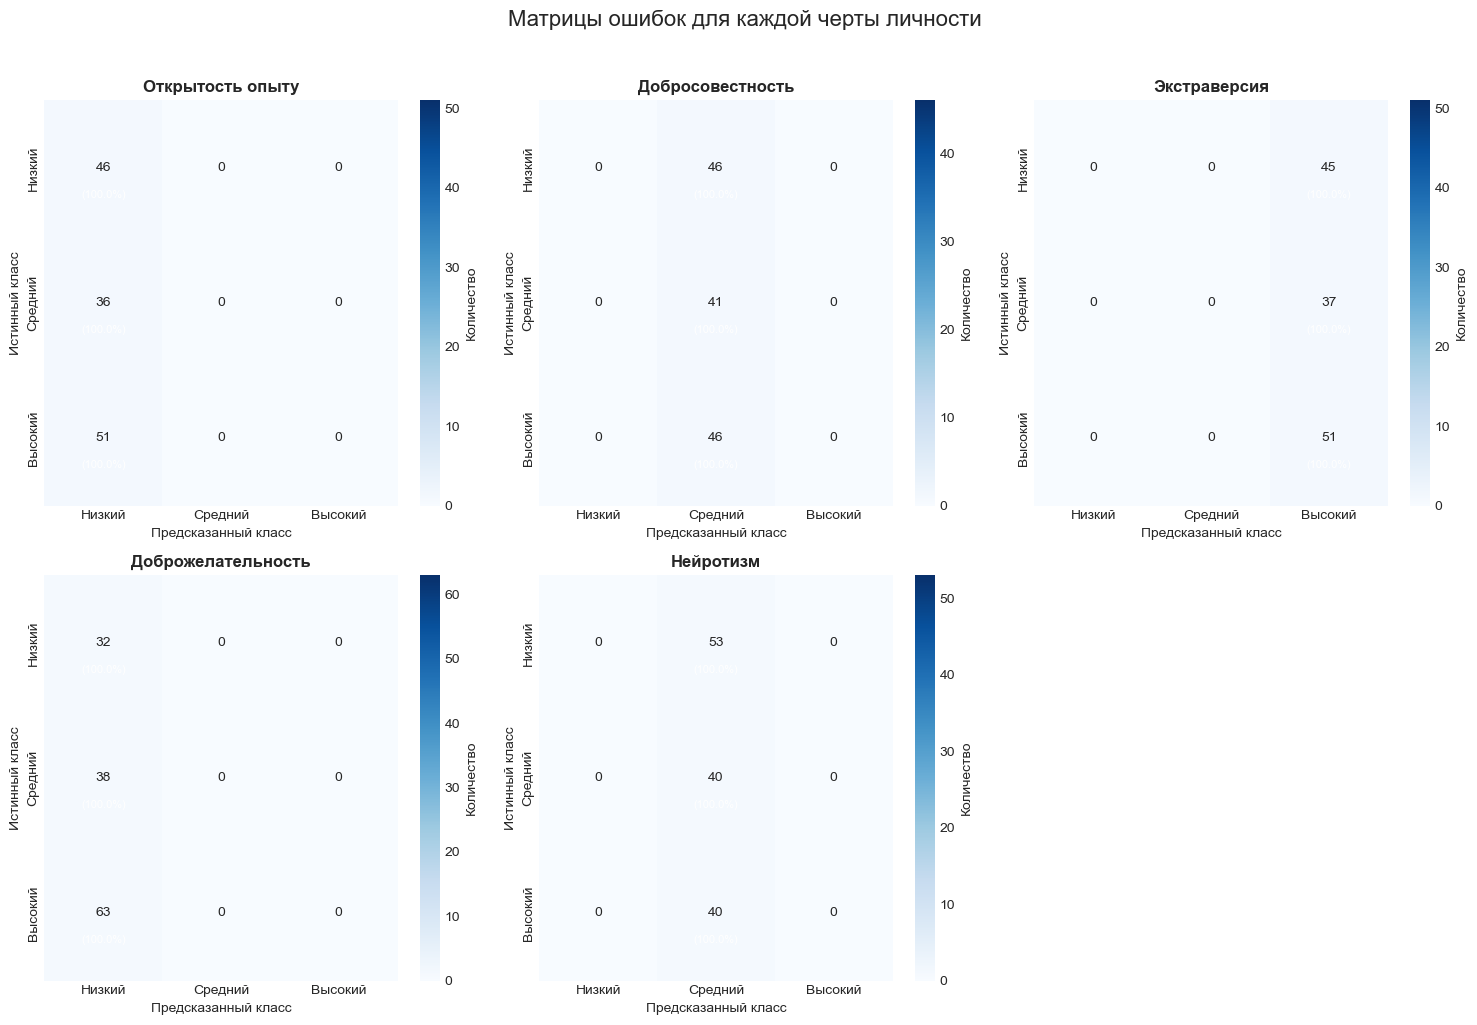

✓ Матрицы ошибок сохранены в confusion_matrices.png


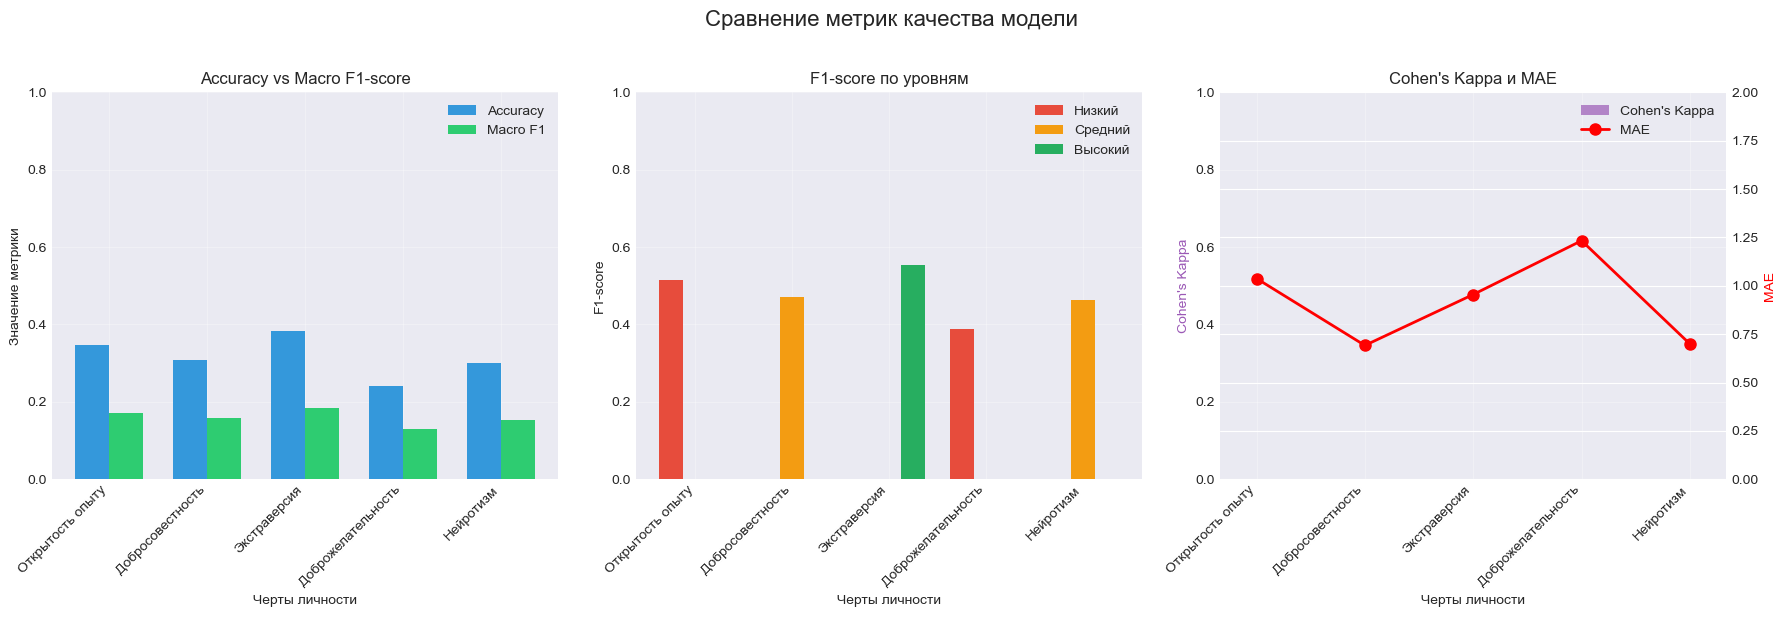

✓ Графики метрик сохранены в metrics_comparison.png


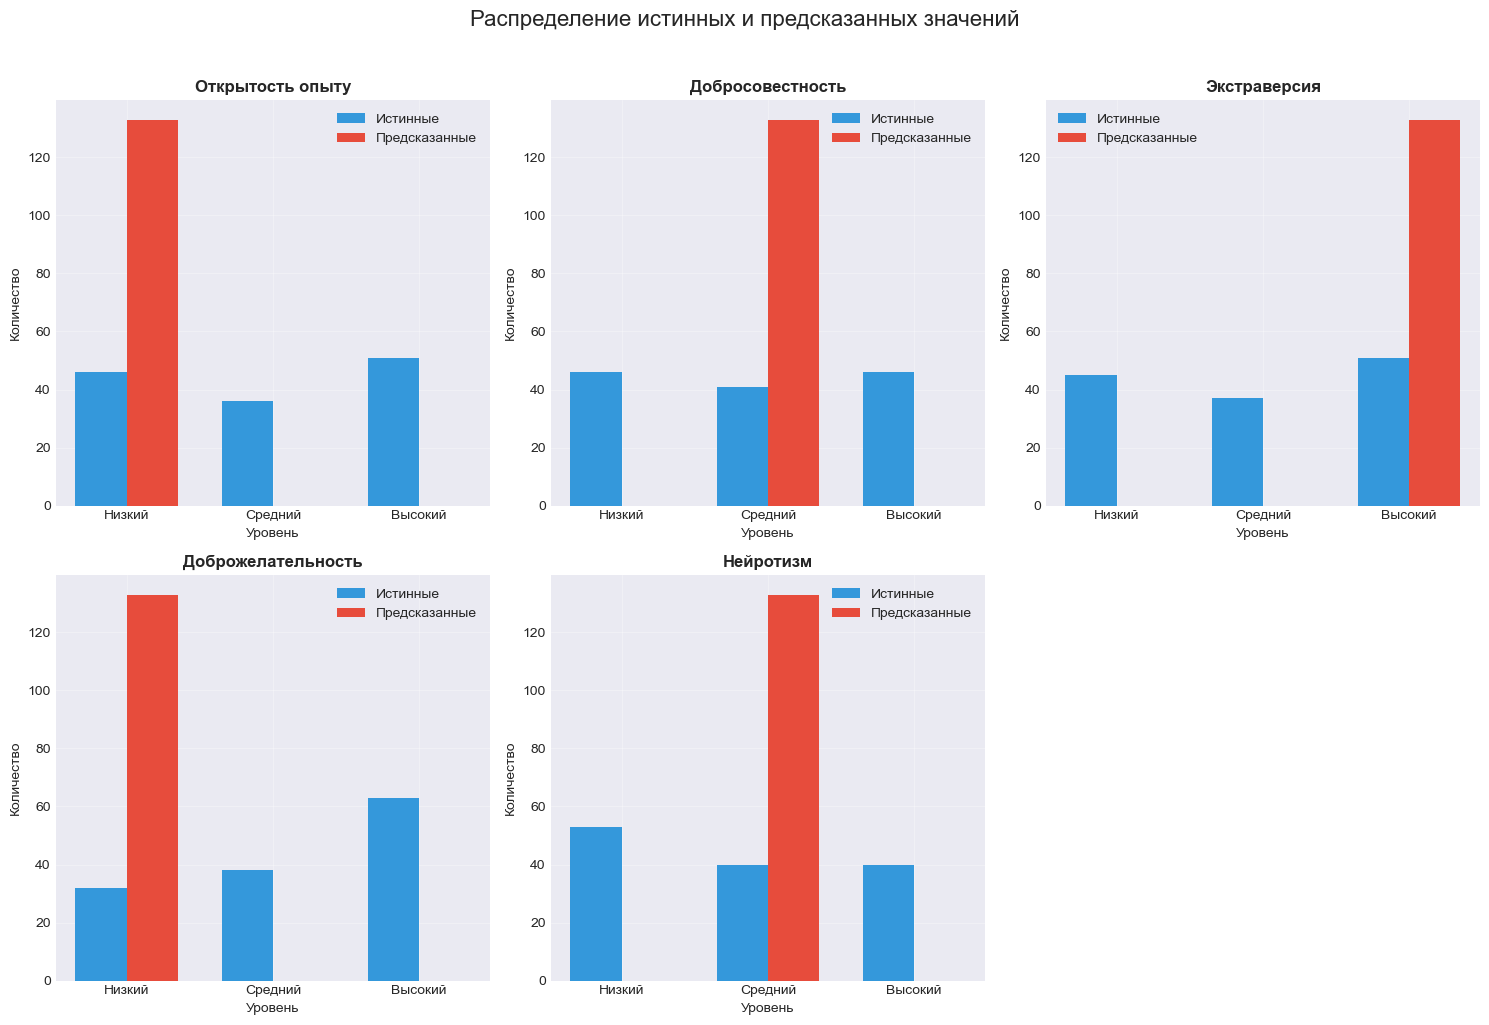

✓ Распределение предсказаний сохранено в prediction_distribution.png


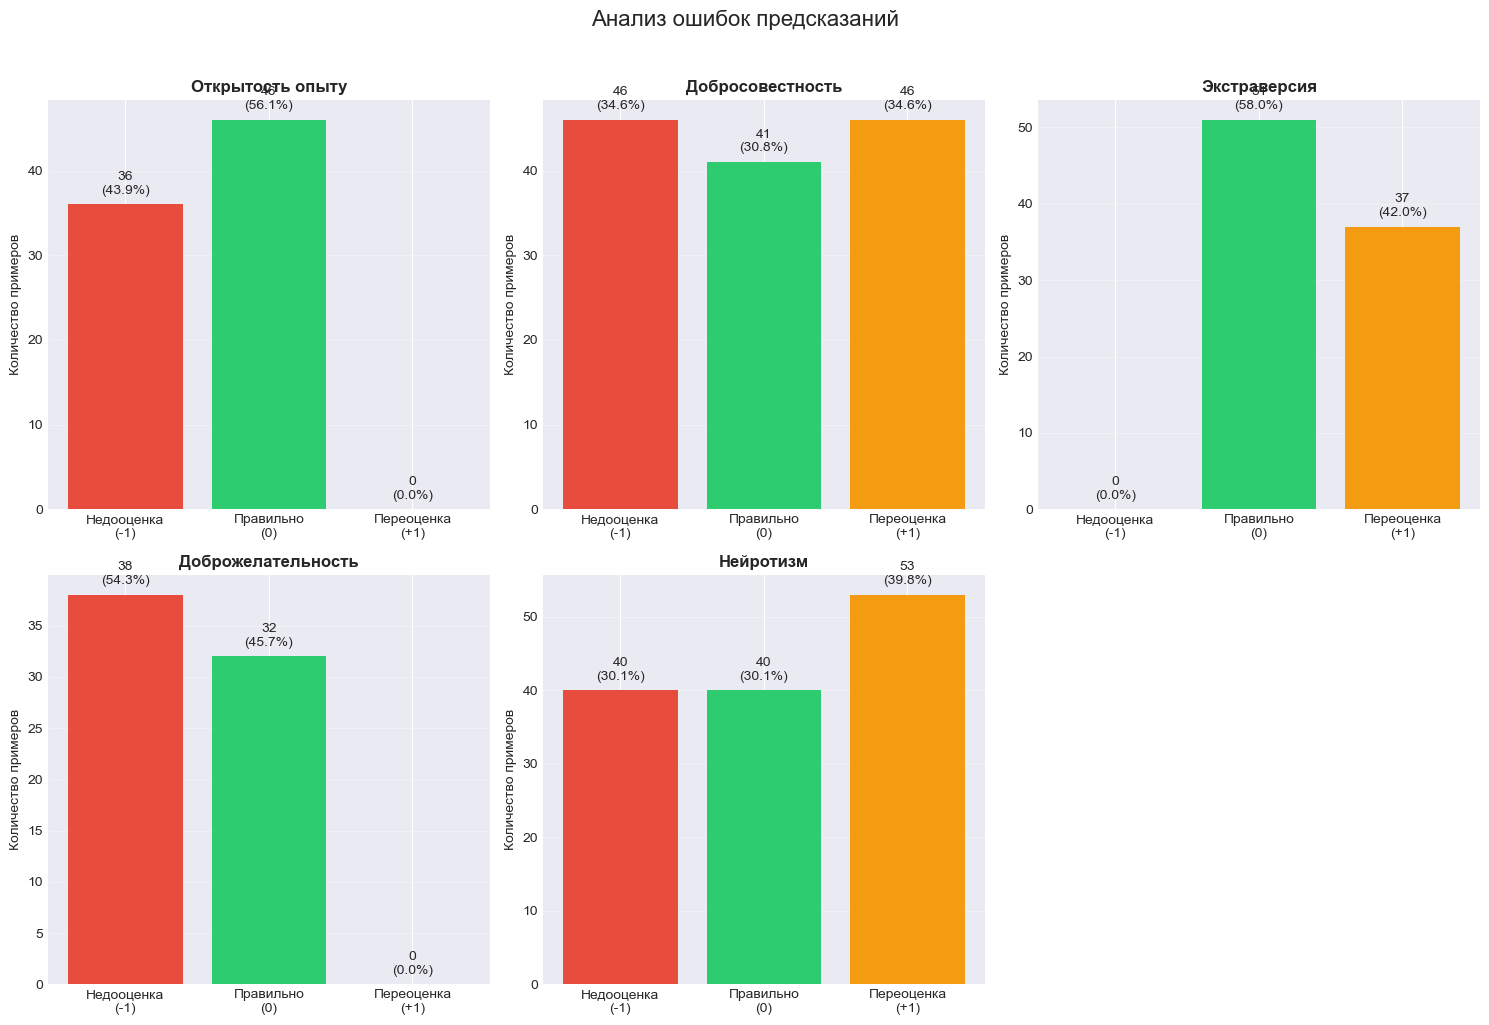

✓ Анализ ошибок сохранен в error_analysis.png

✓ Полный отчет сохранен в evaluation_report.txt

ИТОГОВОЕ САММАРИ
Overall Accuracy: 0.316
Exact Match Ratio: 0.000

Лучшая черта по F1: экстраверсия
Худшая черта по F1: доброжелательность

ДОПОЛНИТЕЛЬНАЯ ОЦЕНКА НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ

ОЦЕНКА НА VALIDATION ВЫБОРКЕ
Анализ 50 примеров...


Прогресс: 100%|████████████████████████████████████████████████████████████████████████| 50/50 [00:06<00:00,  8.16it/s]


✓ Успешно обработано: 50 примеров
✗ Не удалось извлечь предсказания: 0 примеров

ВЫЧИСЛЕНИЕ МЕТРИК

1. ОБЩАЯ ТОЧНОСТЬ (Accuracy)
----------------------------------------
Открытость опыту    : 0.340
Добросовестность    : 0.240
Экстраверсия        : 0.400
Доброжелательность  : 0.340
Нейротизм           : 0.400

Общая точность      : 0.344

2. ДЕТАЛЬНЫЕ МЕТРИКИ ПО КЛАССАМ
----------------------------------------

Открытость опыту:
  Класс    Precision  Recall    F1-score  Support
  ---------------------------------------------
  Низкий   0.340     1.000    0.507     17
  Средний  0.000     0.000    0.000     19
  Высокий  0.000     0.000    0.000     14
  ─────────────────────────────────────────────
  Macro avg  0.113     0.333    0.169     50
  Weighted   0.116     0.340    0.173     50

Добросовестность:
  Класс    Precision  Recall    F1-score  Support
  ---------------------------------------------
  Низкий   0.000     0.000    0.000     23
  Средний  0.240     1.000    0.387     12

In [10]:
import json
import torch
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    mean_absolute_error
)
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей для графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

class ModelEvaluator:
    """
    Класс для полной оценки модели анализа личности
    """
    
    def __init__(
        self,
        base_model_name="Vikhrmodels/Vikhr-Qwen-2.5-0.5B-Instruct",
        lora_weights_path="./personality_model_vikhr/lora_weights",
        test_file="test_prompts_0shot_clean.jsonl",
        val_file="val_prompts_0shot_clean.jsonl"
    ):
        """
        Инициализация оценщика модели
        """
        print("="*60)
        print("ЗАГРУЗКА МОДЕЛИ И ДАННЫХ ДЛЯ ОЦЕНКИ")
        print("="*60)
        
        # Загружаем модель
        print("\n1. Загрузка модели...")
        self.tokenizer = AutoTokenizer.from_pretrained(base_model_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        
        self.model = AutoModelForCausalLM.from_pretrained(
            base_model_name,
            torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
            device_map="auto",
            trust_remote_code=True
        )
        self.model = PeftModel.from_pretrained(self.model, lora_weights_path)
        self.model.eval()
        
        # Загружаем данные
        print("2. Загрузка тестовых данных...")
        self.test_data = self._load_jsonl(test_file)
        self.val_data = self._load_jsonl(val_file)
        
        print(f"   Загружено: {len(self.test_data)} тестовых, {len(self.val_data)} валидационных примеров")
        
        # Определяем признаки
        self.traits = [
            "открытость_опыту",
            "добросовестность",
            "экстраверсия",
            "доброжелательность",
            "нейротизм"
        ]
        
        self.trait_names_ru = [
            "Открытость опыту",
            "Добросовестность", 
            "Экстраверсия",
            "Доброжелательность",
            "Нейротизм"
        ]
        
        self.level_names = {0: "Низкий", 1: "Средний", 2: "Высокий"}
        
        # Результаты
        self.results = None
        self.metrics = None
        
    def _load_jsonl(self, file_path):
        """Загрузка JSONL файла"""
        data = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    data.append(json.loads(line))
        return data
    
    def _extract_json(self, text):
        """Извлечение JSON из ответа модели"""
        # Попытка найти точный JSON с ключами
        json_pattern = r'\{[^{}]*"открытость_опыту"[^{}]*\}'
        match = re.search(json_pattern, text)
        if match:
            try:
                result = json.loads(match.group())
                if all(key in result for key in self.traits):
                    return result
            except:
                pass
        
        # Поиск любого валидного JSON
        json_pattern = r'\{[^{}]*\}'
        matches = re.findall(json_pattern, text)
        for match_str in matches:
            try:
                result = json.loads(match_str)
                if sum(1 for key in self.traits if key in result) >= 3:
                    return result
            except:
                continue
        
        return None
    
    def _generate_prediction(self, prompt):
        """Генерация предсказания для одного примера"""
        inputs = self.tokenizer(prompt, return_tensors="pt")
        input_ids = inputs.input_ids.to(self.model.device)
        attention_mask = inputs.attention_mask.to(self.model.device)
        
        with torch.no_grad():
            outputs = self.model.generate(
                input_ids,
                attention_mask=attention_mask,
                max_new_tokens=100,
                do_sample=False,
                pad_token_id=self.tokenizer.eos_token_id,
                eos_token_id=self.tokenizer.eos_token_id
            )
        
        generated_text = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        predictions = self._extract_json(generated_text)
        
        return predictions, generated_text
    
    def evaluate_on_dataset(self, dataset, dataset_name="test", max_samples=None):
        """
        Оценка модели на датасете
        """
        print(f"\n{'='*60}")
        print(f"ОЦЕНКА НА {dataset_name.upper()} ВЫБОРКЕ")
        print(f"{'='*60}")
        
        if max_samples:
            dataset = dataset[:max_samples]
        
        results = []
        failed_predictions = 0
        
        print(f"Анализ {len(dataset)} примеров...")
        for item in tqdm(dataset, desc="Прогресс"):
            true_labels = item["true_labels_russian"]
            prompt = item["prompt"]
            
            predicted_labels, generated_text = self._generate_prediction(prompt)
            
            if predicted_labels is None:
                failed_predictions += 1
                predicted_labels = {trait: -1 for trait in self.traits}
            
            results.append({
                "user_id": item["user_id"],
                "true_labels": true_labels,
                "predicted_labels": predicted_labels,
                "generated_text": generated_text
            })
        
        print(f"\n✓ Успешно обработано: {len(dataset)} примеров")
        print(f"✗ Не удалось извлечь предсказания: {failed_predictions} примеров")
        
        return results
    
    def compute_metrics(self, results):
        """
        Вычисление всех метрик
        """
        print(f"\n{'='*60}")
        print("ВЫЧИСЛЕНИЕ МЕТРИК")
        print(f"{'='*60}")
        
        metrics = {}
        
        # 1. Общая точность (accuracy)
        print("\n1. ОБЩАЯ ТОЧНОСТЬ (Accuracy)")
        print("-"*40)
        
        all_true = []
        all_pred = []
        
        for trait in self.traits:
            true_values = []
            pred_values = []
            
            for result in results:
                true_val = result["true_labels"].get(trait)
                pred_val = result["predicted_labels"].get(trait, -1)
                
                # Пропускаем неудачные предсказания
                if pred_val != -1 and true_val is not None:
                    true_values.append(true_val)
                    pred_values.append(pred_val)
            
            if true_values:
                acc = accuracy_score(true_values, pred_values)
                metrics[f"{trait}_accuracy"] = acc
                
                all_true.extend(true_values)
                all_pred.extend(pred_values)
                
                print(f"{self.trait_names_ru[self.traits.index(trait)]:20}: {acc:.3f}")
        
        # Общая accuracy
        overall_accuracy = accuracy_score(all_true, all_pred)
        metrics["overall_accuracy"] = overall_accuracy
        print(f"\n{'Общая точность':20}: {overall_accuracy:.3f}")
        
        # 2. Precision, Recall, F1-score для каждого класса
        print("\n2. ДЕТАЛЬНЫЕ МЕТРИКИ ПО КЛАССАМ")
        print("-"*40)
        
        for trait in self.traits:
            true_values = []
            pred_values = []
            
            for result in results:
                true_val = result["true_labels"].get(trait)
                pred_val = result["predicted_labels"].get(trait, -1)
                
                if pred_val != -1 and true_val is not None:
                    true_values.append(true_val)
                    pred_values.append(pred_val)
            
            if true_values:
                precision, recall, f1, support = precision_recall_fscore_support(
                    true_values, pred_values, labels=[0, 1, 2], average=None
                )
                
                metrics[f"{trait}_precision"] = precision
                metrics[f"{trait}_recall"] = recall
                metrics[f"{trait}_f1"] = f1
                
                print(f"\n{self.trait_names_ru[self.traits.index(trait)]}:")
                print(f"  Класс    Precision  Recall    F1-score  Support")
                print(f"  {'-'*45}")
                
                class_metrics = []
                for i, (level, prec, rec, f1_val, supp) in enumerate(zip(
                    ["Низкий", "Средний", "Высокий"], precision, recall, f1, support
                )):
                    print(f"  {level:8} {prec:.3f}     {rec:.3f}    {f1_val:.3f}     {supp}")
                    class_metrics.append({
                        "level": level,
                        "precision": prec,
                        "recall": rec,
                        "f1": f1_val,
                        "support": supp
                    })
                
                metrics[f"{trait}_class_metrics"] = class_metrics
                
                # Средние значения
                macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
                    true_values, pred_values, average='macro'
                )
                weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
                    true_values, pred_values, average='weighted'
                )
                
                metrics[f"{trait}_macro_f1"] = macro_f1
                metrics[f"{trait}_weighted_f1"] = weighted_f1
                
                print(f"  {'─'*45}")
                print(f"  Macro avg  {macro_precision:.3f}     {macro_recall:.3f}    {macro_f1:.3f}     {len(true_values)}")
                print(f"  Weighted   {weighted_precision:.3f}     {weighted_recall:.3f}    {weighted_f1:.3f}     {len(true_values)}")
        
        # 3. Cohen's Kappa
        print("\n3. COHEN'S KAPPA (Согласованность)")
        print("-"*40)
        
        for trait in self.traits:
            true_values = []
            pred_values = []
            
            for result in results:
                true_val = result["true_labels"].get(trait)
                pred_val = result["predicted_labels"].get(trait, -1)
                
                if pred_val != -1 and true_val is not None:
                    true_values.append(true_val)
                    pred_values.append(pred_val)
            
            if true_values:
                kappa = cohen_kappa_score(true_values, pred_values)
                metrics[f"{trait}_kappa"] = kappa
                print(f"{self.trait_names_ru[self.traits.index(trait)]:20}: {kappa:.3f}")
        
        # 4. MAE (Mean Absolute Error)
        print("\n4. СРЕДНЯЯ АБСОЛЮТНАЯ ОШИБКА (MAE)")
        print("-"*40)
        
        for trait in self.traits:
            true_values = []
            pred_values = []
            
            for result in results:
                true_val = result["true_labels"].get(trait)
                pred_val = result["predicted_labels"].get(trait, -1)
                
                if pred_val != -1 and true_val is not None:
                    true_values.append(true_val)
                    pred_values.append(pred_val)
            
            if true_values:
                mae = mean_absolute_error(true_values, pred_values)
                metrics[f"{trait}_mae"] = mae
                print(f"{self.trait_names_ru[self.traits.index(trait)]:20}: {mae:.3f}")
        
        # 5. Exact Match Ratio
        print("\n5. ТОЧНОСТЬ ПОЛНОГО СОВПАДЕНИЯ")
        print("-"*40)
        
        exact_matches = 0
        partial_matches = {i: 0 for i in range(6)}  # 0-5 совпадений
        
        for result in results:
            if all(v != -1 for v in result["predicted_labels"].values()):
                matches = sum(
                    1 for trait in self.traits
                    if result["true_labels"].get(trait) == result["predicted_labels"].get(trait)
                )
                partial_matches[matches] += 1
                if matches == 5:
                    exact_matches += 1
        
        total_valid = sum(partial_matches.values())
        if total_valid > 0:
            exact_match_ratio = exact_matches / total_valid
            metrics["exact_match_ratio"] = exact_match_ratio
            print(f"Полное совпадение (5/5): {exact_match_ratio:.3f} ({exact_matches}/{total_valid})")
            
            for i in range(6):
                print(f"  {i}/5 совпадений: {partial_matches[i]}/{total_valid} ({partial_matches[i]/total_valid:.3f})")
        
        self.metrics = metrics
        return metrics
    
    def plot_confusion_matrices(self, results, save_path="confusion_matrices.png"):
        """
        Построение матриц ошибок
        """
        print(f"\n{'='*60}")
        print("ПОСТРОЕНИЕ МАТРИЦ ОШИБОК")
        print(f"{'='*60}")
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, trait in enumerate(self.traits):
            true_values = []
            pred_values = []
            
            for result in results:
                true_val = result["true_labels"].get(trait)
                pred_val = result["predicted_labels"].get(trait, -1)
                
                if pred_val != -1 and true_val is not None:
                    true_values.append(true_val)
                    pred_values.append(pred_val)
            
            if true_values:
                cm = confusion_matrix(true_values, pred_values, labels=[0, 1, 2])
                
                # Нормализация по строкам
                cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
                
                sns.heatmap(
                    cm_normalized,
                    annot=cm,  # Показываем абсолютные значения
                    fmt='d',
                    cmap='Blues',
                    xticklabels=["Низкий", "Средний", "Высокий"],
                    yticklabels=["Низкий", "Средний", "Высокий"],
                    ax=axes[idx],
                    cbar_kws={'label': 'Количество'},
                    vmin=0,
                    vmax=cm.max() if cm.max() > 0 else 1
                )
                
                # Добавляем проценты
                for i in range(3):
                    for j in range(3):
                        if cm[i][j] > 0:
                            axes[idx].text(
                                j + 0.5, i + 0.7,
                                f'({cm_normalized[i][j]:.1%})',
                                ha='center',
                                va='center',
                                fontsize=8,
                                color='white' if cm_normalized[i][j] > 0.5 else 'black'
                            )
                
                axes[idx].set_title(
                    f'{self.trait_names_ru[idx]}',
                    fontsize=12,
                    fontweight='bold'
                )
                axes[idx].set_xlabel('Предсказанный класс')
                axes[idx].set_ylabel('Истинный класс')
        
        # Убираем лишний subplot
        if len(self.traits) < 6:
            axes[-1].remove()
        
        plt.suptitle('Матрицы ошибок для каждой черты личности', fontsize=16, y=1.02)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✓ Матрицы ошибок сохранены в {save_path}")
    
    def plot_metrics_comparison(self, save_path="metrics_comparison.png"):
        """
        Сравнение метрик для разных черт
        """
        if self.metrics is None:
            print("Сначала вычислите метрики!")
            return
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # График 1: Сравнение accuracy и macro F1
        traits_labels = self.trait_names_ru
        accuracies = [self.metrics.get(f"{trait}_accuracy", 0) for trait in self.traits]
        macro_f1 = [self.metrics.get(f"{trait}_macro_f1", 0) for trait in self.traits]
        
        x = np.arange(len(traits_labels))
        width = 0.35
        
        axes[0].bar(x - width/2, accuracies, width, label='Accuracy', color='#3498db')
        axes[0].bar(x + width/2, macro_f1, width, label='Macro F1', color='#2ecc71')
        
        axes[0].set_xlabel('Черты личности')
        axes[0].set_ylabel('Значение метрики')
        axes[0].set_title('Accuracy vs Macro F1-score')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(traits_labels, rotation=45, ha='right')
        axes[0].legend()
        axes[0].set_ylim([0, 1])
        axes[0].grid(True, alpha=0.3)
        
        # График 2: F1-score по классам
        f1_low = []
        f1_medium = []
        f1_high = []
        
        for trait in self.traits:
            class_metrics = self.metrics.get(f"{trait}_class_metrics", [])
            if class_metrics:
                f1_low.append(class_metrics[0]['f1'])
                f1_medium.append(class_metrics[1]['f1'])
                f1_high.append(class_metrics[2]['f1'])
            else:
                f1_low.append(0)
                f1_medium.append(0)
                f1_high.append(0)
        
        x = np.arange(len(traits_labels))
        width = 0.25
        
        axes[1].bar(x - width, f1_low, width, label='Низкий', color='#e74c3c')
        axes[1].bar(x, f1_medium, width, label='Средний', color='#f39c12')
        axes[1].bar(x + width, f1_high, width, label='Высокий', color='#27ae60')
        
        axes[1].set_xlabel('Черты личности')
        axes[1].set_ylabel('F1-score')
        axes[1].set_title('F1-score по уровням')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(traits_labels, rotation=45, ha='right')
        axes[1].legend()
        axes[1].set_ylim([0, 1])
        axes[1].grid(True, alpha=0.3)
        
        # График 3: Cohen's Kappa и MAE
        kappas = [self.metrics.get(f"{trait}_kappa", 0) for trait in self.traits]
        maes = [self.metrics.get(f"{trait}_mae", 0) for trait in self.traits]
        
        ax1 = axes[2]
        ax2 = ax1.twinx()
        
        bars = ax1.bar(x, kappas, width, label="Cohen's Kappa", color='#9b59b6', alpha=0.7)
        line = ax2.plot(x, maes, 'ro-', label='MAE', linewidth=2, markersize=8)
        
        ax1.set_xlabel('Черты личности')
        ax1.set_ylabel("Cohen's Kappa", color='#9b59b6')
        ax2.set_ylabel('MAE', color='red')
        ax1.set_title("Cohen's Kappa и MAE")
        ax1.set_xticks(x)
        ax1.set_xticklabels(traits_labels, rotation=45, ha='right')
        ax1.set_ylim([0, 1])
        ax2.set_ylim([0, 2])
        ax1.grid(True, alpha=0.3)
        
        # Объединенная легенда
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
        
        plt.suptitle('Сравнение метрик качества модели', fontsize=16, y=1.02)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✓ Графики метрик сохранены в {save_path}")
    
    def plot_prediction_distribution(self, results, save_path="prediction_distribution.png"):
        """
        Распределение предсказаний vs истинных значений
        """
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, trait in enumerate(self.traits):
            true_values = []
            pred_values = []
            
            for result in results:
                true_val = result["true_labels"].get(trait)
                pred_val = result["predicted_labels"].get(trait, -1)
                
                if pred_val != -1 and true_val is not None:
                    true_values.append(true_val)
                    pred_values.append(pred_val)
            
            if true_values:
                # Подсчет распределений
                true_dist = pd.Series(true_values).value_counts().sort_index()
                pred_dist = pd.Series(pred_values).value_counts().sort_index()
                
                x = np.arange(3)
                width = 0.35
                
                true_counts = [true_dist.get(i, 0) for i in range(3)]
                pred_counts = [pred_dist.get(i, 0) for i in range(3)]
                
                axes[idx].bar(x - width/2, true_counts, width, label='Истинные', color='#3498db')
                axes[idx].bar(x + width/2, pred_counts, width, label='Предсказанные', color='#e74c3c')
                
                axes[idx].set_title(self.trait_names_ru[idx], fontweight='bold')
                axes[idx].set_xlabel('Уровень')
                axes[idx].set_ylabel('Количество')
                axes[idx].set_xticks(x)
                axes[idx].set_xticklabels(['Низкий', 'Средний', 'Высокий'])
                axes[idx].legend()
                axes[idx].grid(True, alpha=0.3)
        
        # Убираем лишний subplot
        if len(self.traits) < 6:
            axes[-1].remove()
        
        plt.suptitle('Распределение истинных и предсказанных значений', fontsize=16, y=1.02)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✓ Распределение предсказаний сохранено в {save_path}")
    
    def plot_error_analysis(self, results, save_path="error_analysis.png"):
        """
        Анализ ошибок модели
        """
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, trait in enumerate(self.traits):
            errors = {-1: 0, 0: 0, 1: 0}  # Ошибка на -1, 0, +1
            
            for result in results:
                true_val = result["true_labels"].get(trait)
                pred_val = result["predicted_labels"].get(trait, -1)
                
                if pred_val != -1 and true_val is not None:
                    error = pred_val - true_val  # -1, 0, или 1 (возможные ошибки)
                    if error in errors:
                        errors[error] += 1
            
            error_labels = ['Недооценка\n(-1)', 'Правильно\n(0)', 'Переоценка\n(+1)']
            error_counts = [errors[-1], errors[0], errors[1]]
            colors = ['#e74c3c', '#2ecc71', '#f39c12']
            
            axes[idx].bar(error_labels, error_counts, color=colors)
            axes[idx].set_title(f'{self.trait_names_ru[idx]}', fontweight='bold')
            axes[idx].set_ylabel('Количество примеров')
            axes[idx].grid(True, alpha=0.3, axis='y')
            
            # Добавляем проценты
            total = sum(error_counts)
            for i, count in enumerate(error_counts):
                if total > 0:
                    axes[idx].text(i, count + max(error_counts)*0.02, 
                                 f'{count}\n({count/total:.1%})', 
                                 ha='center', va='bottom')
        
        if len(self.traits) < 6:
            axes[-1].remove()
        
        plt.suptitle('Анализ ошибок предсказаний', fontsize=16, y=1.02)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✓ Анализ ошибок сохранен в {save_path}")
    
    def generate_report(self, results, output_file="evaluation_report.txt"):
        """
        Генерация полного отчета об оценке
        """
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write("="*60 + "\n")
            f.write("ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ АНАЛИЗА ЛИЧНОСТИ\n")
            f.write("="*60 + "\n\n")
            
            f.write(f"Дата оценки: {pd.Timestamp.now()}\n")
            f.write(f"Количество примеров: {len(results)}\n")
            f.write(f"Модель: Vikhr-Qwen-2.5-0.5B-Instruct + LoRA\n\n")
            
            # Общие метрики
            f.write("1. ОБЩИЕ МЕТРИКИ\n")
            f.write("-"*40 + "\n")
            f.write(f"Overall Accuracy: {self.metrics.get('overall_accuracy', 0):.3f}\n")
            f.write(f"Exact Match Ratio: {self.metrics.get('exact_match_ratio', 0):.3f}\n\n")
            
            # По каждой черте
            f.write("2. МЕТРИКИ ПО ЧЕРТАМ ЛИЧНОСТИ\n")
            f.write("-"*40 + "\n")
            
            for i, trait in enumerate(self.traits):
                f.write(f"\n{self.trait_names_ru[i]}:\n")
                f.write(f"  Accuracy: {self.metrics.get(f'{trait}_accuracy', 0):.3f}\n")
                f.write(f"  Macro F1: {self.metrics.get(f'{trait}_macro_f1', 0):.3f}\n")
                f.write(f"  Weighted F1: {self.metrics.get(f'{trait}_weighted_f1', 0):.3f}\n")
                f.write(f"  Cohen's Kappa: {self.metrics.get(f'{trait}_kappa', 0):.3f}\n")
                f.write(f"  MAE: {self.metrics.get(f'{trait}_mae', 0):.3f}\n")
                
                # По классам
                class_metrics = self.metrics.get(f"{trait}_class_metrics", [])
                if class_metrics:
                    f.write(f"  F1 по классам:\n")
                    for cm in class_metrics:
                        f.write(f"    {cm['level']}: {cm['f1']:.3f} (support: {cm['support']})\n")
            
            f.write("\n3. РАСПРЕДЕЛЕНИЕ СОВПАДЕНИЙ\n")
            f.write("-"*40 + "\n")
            
            # Подсчет совпадений
            matches_dist = {i: 0 for i in range(6)}
            for result in results:
                if all(v != -1 for v in result["predicted_labels"].values()):
                    matches = sum(
                        1 for trait in self.traits
                        if result["true_labels"].get(trait) == result["predicted_labels"].get(trait)
                    )
                    matches_dist[matches] += 1
            
            total_valid = sum(matches_dist.values())
            for i in range(6):
                f.write(f"  {i}/5 совпадений: {matches_dist[i]} ({matches_dist[i]/total_valid:.3f})\n")
            
            f.write("\n4. СЛОЖНЫЕ СЛУЧАИ\n")
            f.write("-"*40 + "\n")
            
            # Находим худшие предсказания
            errors = []
            for result in results:
                if all(v != -1 for v in result["predicted_labels"].values()):
                    error_count = sum(
                        1 for trait in self.traits
                        if result["true_labels"].get(trait) != result["predicted_labels"].get(trait)
                    )
                    errors.append((error_count, result))
            
            errors.sort(key=lambda x: x[0], reverse=True)
            
            f.write(f"Топ-5 худших предсказаний (по количеству ошибок):\n\n")
            for i, (error_count, result) in enumerate(errors[:5]):
                f.write(f"  Пример {i+1} (ошибок: {error_count}/5):\n")
                f.write(f"    Истинные: {result['true_labels']}\n")
                f.write(f"    Предсказанные: {result['predicted_labels']}\n")
                f.write(f"    User ID: {result['user_id']}\n\n")
        
        print(f"\n✓ Полный отчет сохранен в {output_file}")
    
    def run_full_evaluation(self, max_test_samples=None):
        """
        Запуск полной оценки модели
        """
        # 1. Оценка на тестовой выборке
        self.results = self.evaluate_on_dataset(
            self.test_data, 
            "test", 
            max_samples=max_test_samples
        )
        
        # 2. Вычисление метрик
        self.metrics = self.compute_metrics(self.results)
        
        # 3. Визуализации
        self.plot_confusion_matrices(self.results)
        self.plot_metrics_comparison()
        self.plot_prediction_distribution(self.results)
        self.plot_error_analysis(self.results)
        
        # 4. Отчет
        self.generate_report(self.results)
        
        # 5. Саммари
        print(f"\n{'='*60}")
        print("ИТОГОВОЕ САММАРИ")
        print(f"{'='*60}")
        print(f"Overall Accuracy: {self.metrics.get('overall_accuracy', 0):.3f}")
        print(f"Exact Match Ratio: {self.metrics.get('exact_match_ratio', 0):.3f}")
        print(f"\nЛучшая черта по F1: {max(self.traits, key=lambda t: self.metrics.get(f'{t}_weighted_f1', 0))}")
        print(f"Худшая черта по F1: {min(self.traits, key=lambda t: self.metrics.get(f'{t}_weighted_f1', 0))}")
        
        return self.metrics


# ============================================
# ЗАПУСК ПОЛНОЙ ОЦЕНКИ
# ============================================

if __name__ == "__main__":
    # Создаем оценщик
    evaluator = ModelEvaluator(
        base_model_name="Vikhrmodels/Vikhr-Qwen-2.5-0.5B-Instruct",
        lora_weights_path="./personality_model_vikhr/lora_weights",
        test_file="test_prompts_0shot_clean.jsonl",
        val_file="val_prompts_0shot_clean.jsonl"
    )
    
    # Запускаем полную оценку
    # max_test_samples=None - использовать все примеры
    # max_test_samples=50 - только 50 примеров (для быстроты)
    metrics = evaluator.run_full_evaluation(max_test_samples=None)
    
    # Дополнительно: оценка на валидационной выборке
    print(f"\n{'='*60}")
    print("ДОПОЛНИТЕЛЬНАЯ ОЦЕНКА НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ")
    print(f"{'='*60}")
    
    val_results = evaluator.evaluate_on_dataset(
        evaluator.val_data[:50],  # Первые 50 примеров
        "validation"
    )
    val_metrics = evaluator.compute_metrics(val_results)

{"user_id": 13144557, "prompt": "# Задача\nВыполните анализ личности пользователя социальной сети на основе его публикаций. Оцените каждую из пяти черт личности по шкале: 0 - низкий уровень, 1 - средний уровень, 2 - высокий уровень. Ответ предоставьте строго в JSON-формате без дополнительного текста.\n\n# Описание черт личности\n- Открытость опыту: любознательность, креативность, воображение, интерес к новым идеям и эстетическим переживаниям\n- Добросовестность: организованность, дисциплина, надёжность, целеустремлённость, внимание к деталям\n- Экстраверсия: общительность, энергичность, напористость, склонность к социальным взаимодействиям\n- Доброжелательность: эмпатия, готовность помогать, доверие к людям, склонность к сотрудничеству\n- Нейротизм: эмоциональная нестабильность, тревожность, раздражительность, подверженность стрессу\n# Информация о пользователе\nПол: Female\nВозраст: 32.0\n\n# Публикации пользователя\nSOS!!! Сегодня ночью произошло ДТП. Наше авто пострадало, а виновник ДТП скрылся. Помогите найти авто виновника! Нам нужны данные его страховки ( в противном случае ущерб страховая компания возмещать отказалась) МЫ ИЩЕМ MITSUBISHI Outlander серебристого цвета, на заднем бампере глубокая вмятина с левой ( водительской стороны)! Если Вы знаете, что\n\n# Формат ответа\n{\"открытость_опыту\": 0, \"добросовестность\": 1, \"экстраверсия\": 2, \"доброжелательность\": 0, \"нейротизм\": 1}", "true_labels_russian": {"открытость_опыту": 1, "добросовестность": 0, "экстраверсия": 1, "доброжелательность": 0, "нейротизм": 2}}


{"user_id": 13144557, "prompt": "# Задача\nВыполните анализ личности пользователя социальной сети на основе его публикаций. Оцените каждую из пяти черт личности по шкале: 0 - низкий уровень, 1 - средний уровень, 2 - высокий уровень. Ответ предоставьте строго в JSON-формате без дополнительного текста.\n\n# Описание черт личности\n- Открытость опыту: любознательность, креативность, воображение, интерес к новым идеям и эстетическим переживаниям\n- Добросовестность: организованность, дисциплина, надёжность, целеустремлённость, внимание к деталям\n- Экстраверсия: общительность, энергичность, напористость, склонность к социальным взаимодействиям\n- Доброжелательность: эмпатия, готовность помогать, доверие к людям, склонность к сотрудничеству\n- Нейротизм: эмоциональная нестабильность, тревожность, раздражительность, подверженность стрессу\n# Примеры анализа\n\nПример 1:\n# Публикации пользователя\nЦитата: Говорят, что убивший дракона сам становится драконом. Это было бы вовсе не плохо. Но, к сожалению, убийца остается человеком. | Цитата: Драконы не пасутся на свежем воздухе, их единственная пища – грибы, которые они выращивают в своих глубоких пещерах. – Но принцессы-то! Вы же не станете отрицать, что дракон похитил принцессу при многочисленных свидетелях? Зачем она ему, в таком случае? – Ну как же, – пробормотал дракон, – грибочкам ведь\n# Ответ\n{\"открытость_опыту\": 1, \"добросовестность\": 0, \"экстраверсия\": 0, \"доброжелательность\": 2, \"нейротизм\": 2}\n\nПример 2:\n# Публикации пользователя\nНу все, до свидания | Телефон умер, товарищи, напишите номеров! | Peppermint candies and Sunday work... | АЛЬФ! | Ну чем не лепс? | вот это молдавский задор! | Hello | Адово жду тебя на нашем предновогоднем концерте !!! | Ну последний рабочий день этого года в Ъ аминь! | с наступающим! | С НАСТУПАЮЩИМ !!! | ▼ нажми на картинку\n# Ответ\n{\"открытость_опыту\": 0, \"добросовестность\": 1, \"экстраверсия\": 1, \"доброжелательность\": 0, \"нейротизм\": 0}\n\nПример 3:\n# Публикации пользователя\nТак и живём...🐋💙💙🎼🎵🎶🎤🎧 | когда_ты_художник живопись натюрморт | Старое) рисовала год назад)) | новые_очечи зрение_-2,5 B612 | вот что мне нужно для счастья😍😍 | бедный | и батик с резервом😂😂 | оу дааа | Смотрите \"Дети и родители, которые похожи как две капли воды\" на YouTube | Погуляли😹 | Погуляли😂😎😺😺😺😺 | Стихи Есенина, очень трогательные, порой даже печальные... Сестре Шуре Ах, как много на свете кошек, Нам с тобой их не счесть никогда. Сердцу снится душистый горошек, И звенит голубая звезда. Наяву ли, в бреду иль спросонок, Только помню с далекого дня - На лежанке мурлыкал котенок, Безразлично смотря на меня.\n# Ответ\n{\"открытость_опыту\": 1, \"добросовестность\": 1, \"экстраверсия\": 1, \"доброжелательность\": 1, \"нейротизм\": 2}\n\n# Информация о пользователе\nПол: Female\nВозраст: 32.0\n\n# Публикации пользователя\nSOS!!! Сегодня ночью произошло ДТП. Наше авто пострадало, а виновник ДТП скрылся. Помогите найти авто виновника! Нам нужны данные его страховки ( в противном случае ущерб страховая компания возмещать отказалась) МЫ ИЩЕМ MITSUBISHI Outlander серебристого цвета, на заднем бампере глубокая вмятина с левой ( водительской стороны)! Если Вы знаете, что\n\n# Формат ответа\n{\"открытость_опыту\": 0, \"добросовестность\": 1, \"экстраверсия\": 2, \"доброжелательность\": 0, \"нейротизм\": 1}", "true_labels_russian": {"открытость_опыту": 1, "добросовестность": 0, "экстраверсия": 1, "доброжелательность": 0, "нейротизм": 2}}
